In [217]:
import sys

sys.path.append("..")

import pandas as pd 
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression , Lasso , Ridge , ElasticNet
from sklearn.ensemble import RandomForestRegressor

from src.data.cleaning import (
    clean_dataset
)

from src.features.engineering import (
    create_features
)

In [218]:
DATA_PATH='../data/raw/car details v4.csv'

df=pd.read_csv(DATA_PATH)
df=clean_dataset(df)
df=df.drop(columns=['torque','engine','max_power'])


## Seprating Target


In [219]:
X=df.drop(columns='selling_price')
y=df['selling_price']

## Train Test Split

In [220]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

## Creating features

In [221]:
X_train=create_features(X_train)
X_test=create_features(X_test)

## Identifying Numerical and Categorical Fetaures

In [222]:
numeric_features= X_train.select_dtypes(
    include="number"
).columns.tolist()
categorical_features= X_train.select_dtypes(
    exclude="number"
).columns.tolist()


print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['year', 'km_driven', 'mileage', 'seats', 'engine_cc', 'max_power_bhp', 'torque_nm', 'torque_rpm_min', 'torque_rpm_max', 'age']
Categorical: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']


In [223]:
numeric_pipeline=Pipeline([
    ( 
        'imputer',
        SimpleImputer(strategy='median')
    ),(
        'scaler',
        StandardScaler()
    )
])

In [224]:
categorical_pipeline=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        )
    )
])

In [225]:
preprocessor=ColumnTransformer(
    transformers=[
        ('numeric',
        numeric_pipeline,
        numeric_features),
        (
            'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [226]:
baseline_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Linear Regression',LinearRegression())
])

In [227]:
ridge_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Ridge',Ridge(alpha=10.0))
])

In [228]:
lasso_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Lasso',Lasso(alpha=0.001,max_iter=10000))
])

In [236]:
elastic_model=Pipeline([
    ('preprocessor',preprocessor),
    ("Elastic",ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000,
))
])

In [237]:
# Baseline Model
y_log=np.log1p(y_train)
baseline_model.fit(X_train,y_log)

# Ridge Model
ridge_model.fit(X_train,y_log)

# Lasso Model
lasso_model.fit(X_train,y_log)

# Elastic Model
elastic_model.fit(X_train,y_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Elastic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['year','km_driven','fuel',...,'torque_rpm_max','brand','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of co

In [230]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


Linear Regression
MAE:  90,851.46
RMSE: 167,728.03
R²:   0.8717

Residual statistics:
count    1.386000e+03
mean     1.512582e+04
std      1.671049e+05
min     -2.415404e+06
25%     -4.750445e+04
50%      3.345201e+03
75%      7.444489e+04
max      2.284303e+06
Name: selling_price, dtype: float64


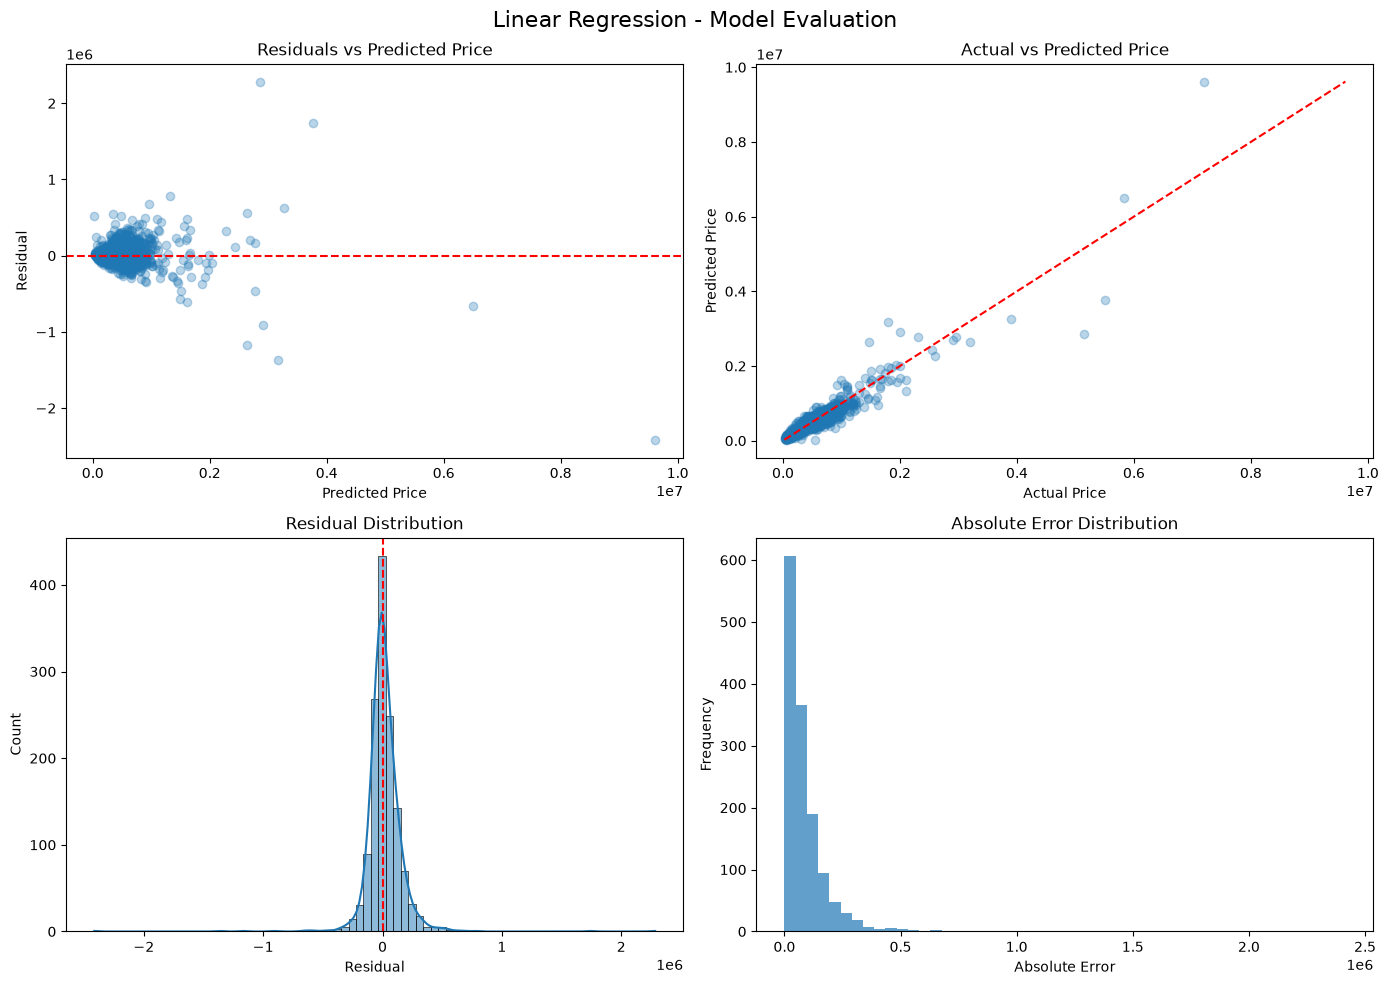


Ridge Regression
MAE:  91,944.22
RMSE: 171,262.35
R²:   0.8663

Residual statistics:
count    1.386000e+03
mean     1.691607e+04
std      1.704864e+05
min     -1.867740e+06
25%     -4.673774e+04
50%      1.081148e+03
75%      7.310179e+04
max      2.457354e+06
Name: selling_price, dtype: float64


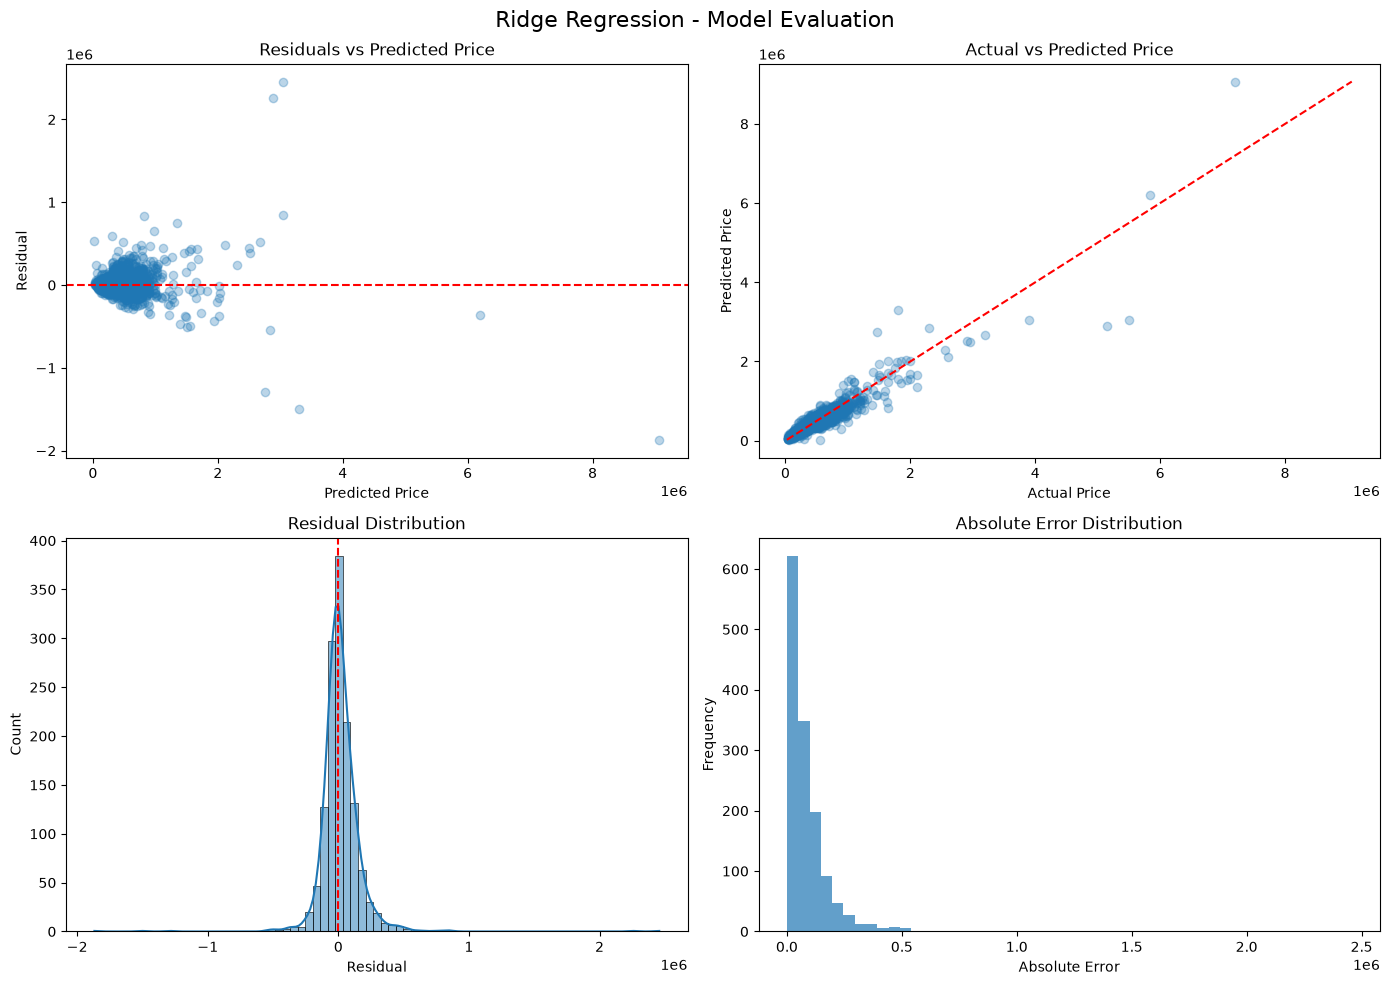


Lasso Regression
MAE:  93,540.24
RMSE: 175,863.33
R²:   0.8590

Residual statistics:
count    1.386000e+03
mean     1.798866e+04
std      1.750040e+05
min     -1.520463e+06
25%     -4.795742e+04
50%      1.734366e+03
75%      7.355541e+04
max      2.876056e+06
Name: selling_price, dtype: float64


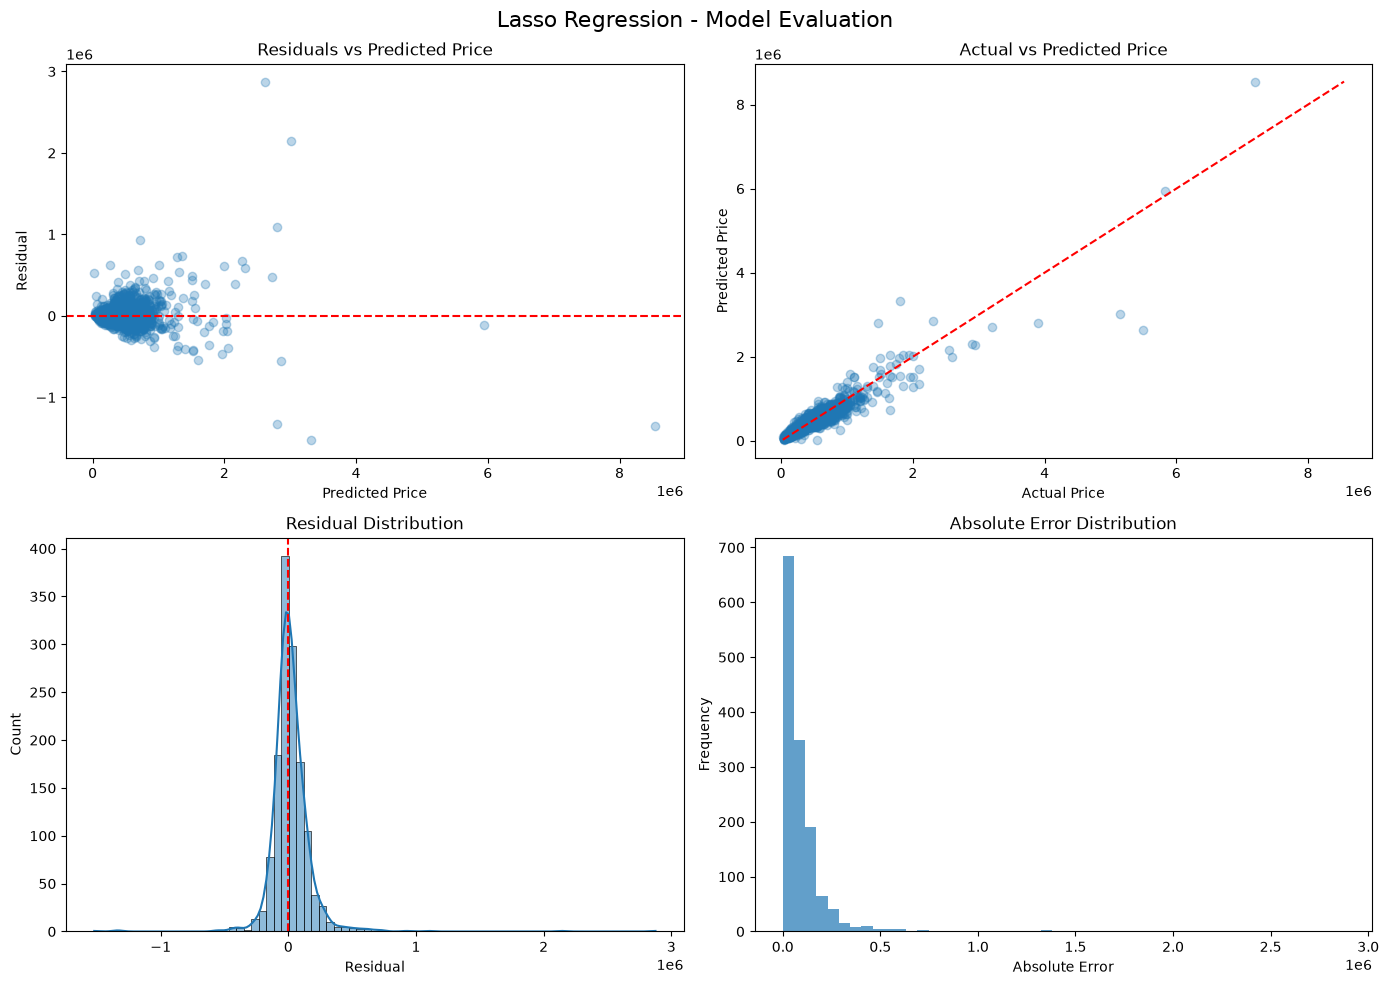


ElasticNet Regression
MAE:  92,792.76
RMSE: 176,312.30
R²:   0.8583

Residual statistics:
count    1.386000e+03
mean     1.724344e+04
std      1.755304e+05
min     -1.759436e+06
25%     -4.697426e+04
50%      1.399801e+03
75%      7.349664e+04
max      2.893625e+06
Name: selling_price, dtype: float64


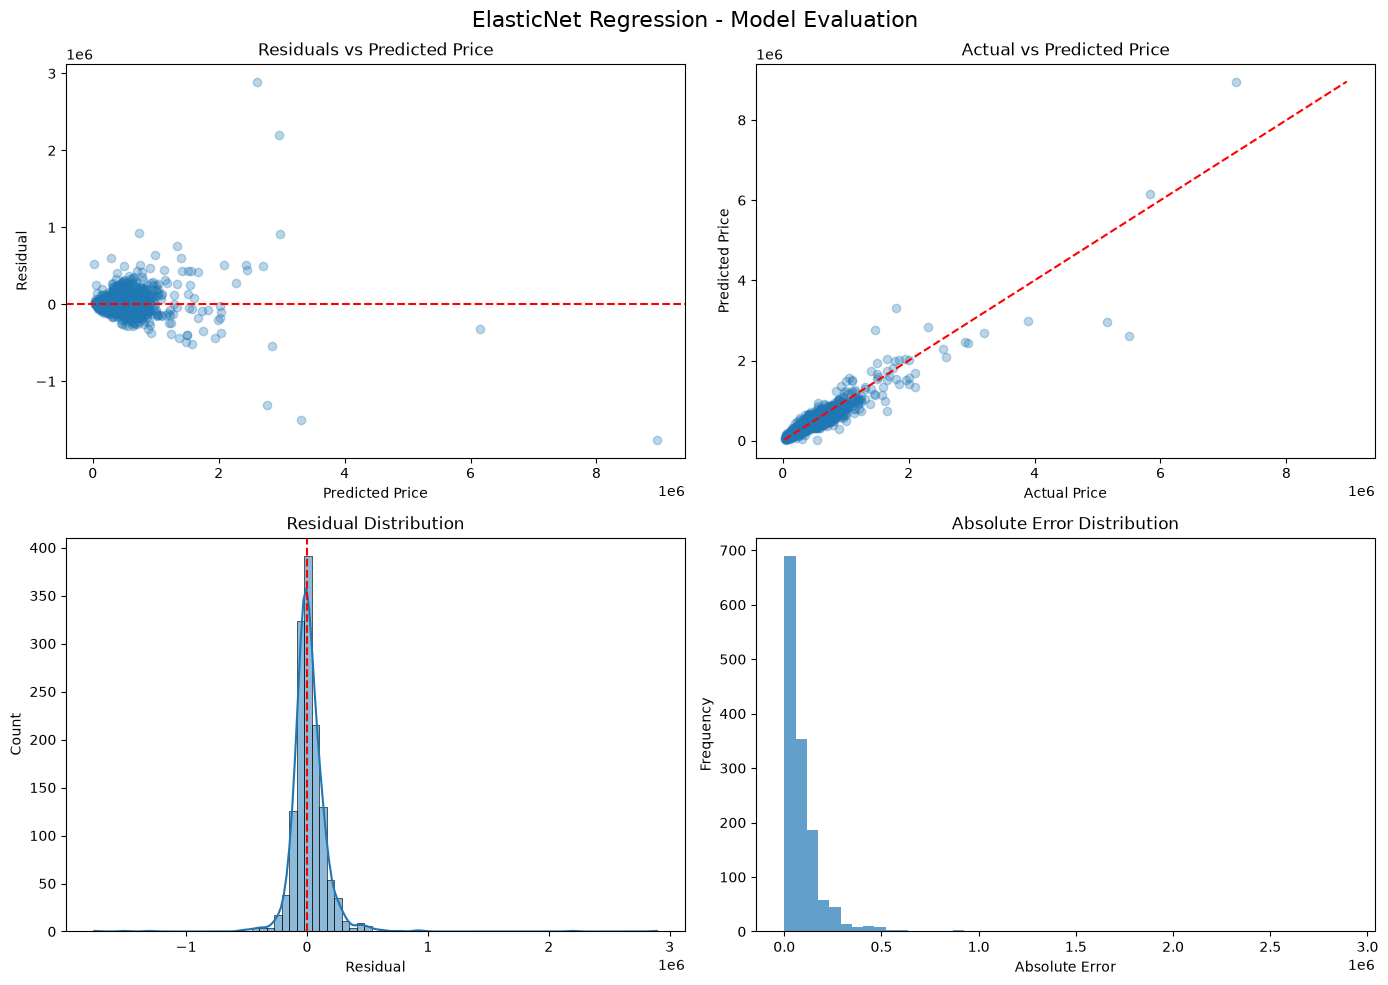

In [238]:
models = {
    "Linear Regression": baseline_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression":lasso_model,
    "ElasticNet Regression":elastic_model
}




def evaluate_model(model, X_test, y_test, model_name):
    
    # Predict
    y_pred_log = model.predict(X_test)
    
    # Convert predictions back to original price scale
    y_pred = np.expm1(y_pred_log)
    
    # Residuals
    residuals = y_test - y_pred
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    
    print("\nResidual statistics:")
    print(pd.Series(residuals).describe())
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuals vs predicted
    axes[0, 0].scatter(
        y_pred,
        residuals,
        alpha=0.3
    )
    axes[0, 0].axhline(
        0,
        color="red",
        linestyle="--"
    )
    axes[0, 0].set_xlabel("Predicted Price")
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].set_title("Residuals vs Predicted Price")
    
    # 2. Actual vs predicted
    axes[0, 1].scatter(
        y_test,
        y_pred,
        alpha=0.3
    )
    
    # Perfect prediction line
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    
    axes[0, 1].plot(
        [min_value, max_value],
        [min_value, max_value],
        color="red",
        linestyle="--"
    )
    
    axes[0, 1].set_xlabel("Actual Price")
    axes[0, 1].set_ylabel("Predicted Price")
    axes[0, 1].set_title("Actual vs Predicted Price")
    
    # 3. Residual distribution
    sns.histplot(
        residuals,
        kde=True,
        ax=axes[1, 0]
    )
    axes[1, 0].axvline(
        0,
        color="red",
        linestyle="--"
    )
    axes[1, 0].set_xlabel("Residual")
    axes[1, 0].set_title("Residual Distribution")
    
    # 4. Absolute error
    absolute_errors = np.abs(residuals)
    
    axes[1, 1].hist(
        absolute_errors,
        bins=50,
        alpha=0.7
    )
    axes[1, 1].set_xlabel("Absolute Error")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_title("Absolute Error Distribution")
    
    plt.suptitle(
        f"{model_name} - Model Evaluation",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()
    
    # Return everything so we can reuse it later
    return {
        "model": model_name,
        "predictions": y_pred,
        "residuals": residuals,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
    
    
results = {}

for name, model in models.items():
    results[name] = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )
    